# T-cell repertoire annotation and motif discovery (TCRNET-style)

This notebook demonstrates a highly customized MIR implementation of TCRNET-style analysis for antigen-associated TCR motif discovery. The workflow is inspired by ideas described in the TCRNET framework paper and is not a literal line-by-line reimplementation of the original software.

Samples:

```
(B35+)       HIP02877  A*26 A*33 B*14 B*35  CMV-
(CMV+)       HIP13994  A*02 A*02 B*07 B*44  CMV+
```

Control repertoire:

```
control.txt.gz
```

Inputs:

- `airr_benchmark/tcrnet/CMV+.txt.gz`
- `airr_benchmark/tcrnet/B35+.txt.gz`
- `airr_benchmark/tcrnet/control.txt.gz`
- latest `airr_benchmark/vdjdb/**/vdjdb.slim.txt.gz`

Reference:
Pogorelyy MV, Shugay M. A Framework for Annotation of Antigen Specificities in High-Throughput T-Cell Repertoire Sequencing Studies. *Front Immunol.* 2019;10:2159. doi:10.3389/fimmu.2019.02159. PMID:31616409.
PubMed: https://pubmed.ncbi.nlm.nih.gov/31616409/

In [1]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

from __future__ import annotations

import sys
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, to_rgba
from scipy.stats import binomtest, mannwhitneyu, spearmanr

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.biomarkers.tcrnet import compute_tcrnet
from mir.common.clonotype import Clonotype
from mir.common.filter import filter_functional
from mir.common.parser import ClonotypeTableParser
from mir.common.repertoire import LocusRepertoire
from mir.graph.edit_distance_graph import build_edit_distance_graph
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_slim

CORES = 4
BENCHMARK_ROOT = ensure_airr_benchmark(repo_root, allow_patterns=["tcrnet/**", "vdjdb/**"])
TCRNET_DIR = BENCHMARK_ROOT / "tcrnet"
VDJDB_PATH = find_airr_benchmark_vdjdb_slim(BENCHMARK_ROOT)

SAMPLE_HLAS = {
    'B35+': ['HLA-A*26', 'HLA-A*33', 'HLA-B*14', 'HLA-B*35'],
    'CMV+': ['HLA-A*02', 'HLA-B*07', 'HLA-B*44'],
}

parser = ClonotypeTableParser()


def bh_adjust(p_values: pd.Series) -> pd.Series:
    values = pd.Series(p_values, dtype=float)
    if values.empty:
        return values
    order = np.argsort(values.to_numpy())
    ranked = values.to_numpy()[order]
    n = len(ranked)
    adjusted = np.empty(n, dtype=float)
    running = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        running = min(running, ranked[i] * n / rank)
        adjusted[i] = running
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adjusted, 0.0, 1.0)
    return pd.Series(out, index=values.index)


def load_trb(path: str | Path, sample_id: str) -> LocusRepertoire:
    clones = filter_functional(LocusRepertoire(parser.parse(str(path)), locus='TRB', repertoire_id=sample_id)).clonotypes
    rep = LocusRepertoire(clonotypes=clones, locus='TRB', repertoire_id=sample_id)
    return rep


def repertoire_to_sequence_table(rep: LocusRepertoire, sample_id: str) -> pd.DataFrame:
    rows = []
    total = max(1, rep.duplicate_count)
    for clonotype in rep.clonotypes:
        rows.append(
            {
                'cdr3aa': clonotype.junction_aa,
                'count': clonotype.duplicate_count,
                'v_gene': clonotype.v_gene,
                'j_gene': clonotype.j_gene,
                'sample_id': sample_id,
            }
        )
    df = pd.DataFrame(rows)
    grouped = (
        df.groupby(['cdr3aa', 'sample_id'], as_index=False)
        .agg(count=('count', 'sum'), v_gene=('v_gene', 'first'), j_gene=('j_gene', 'first'))
    )
    grouped['freq'] = grouped['count'] / total
    return grouped


def mhc_a_base(series: pd.Series) -> pd.Series:
    return series.fillna('').astype(str).str.split(':').str[0].str.split(',').str[0]


def load_vdjdb_reference(path: Path) -> tuple[pd.DataFrame, LocusRepertoire]:
    raw = pd.read_csv(path, sep='\t', compression='gzip')
    raw = raw[raw['gene'].eq('TRB')].copy()
    epi_sizes = raw.groupby('antigen.epitope')['cdr3'].nunique()
    raw = raw[raw['antigen.epitope'].map(epi_sizes).ge(30)].reset_index(drop=True)
    raw['mhc.a.base'] = mhc_a_base(raw['mhc.a'])
    raw['epi.name'] = raw['mhc.a.base'].str.replace('HLA-', '', regex=False).str[:6].str.strip() + ' ' + raw['antigen.epitope'].astype(str).str[:3]
    raw['antigen.species'] = raw['antigen.species'].replace({'DENV': 'DengueVirus'})

    clonotypes = []
    for idx, row in raw.iterrows():
        clonotypes.append(
            Clonotype(
                sequence_id=str(idx),
                locus='TRB',
                junction_aa=str(row['cdr3']),
                v_gene=str(row.get('v.segm', '') or ''),
                j_gene=str(row.get('j.segm', '') or ''),
                duplicate_count=1,
                _validate=False,
            )
        )
    return raw, LocusRepertoire(clonotypes=clonotypes, locus='TRB')


def annotate_repertoire_with_vdjdb(rep: LocusRepertoire, sample_id: str, vdjdb_df: pd.DataFrame, vdjdb_rep: LocusRepertoire) -> pd.DataFrame:
    seq_df = repertoire_to_sequence_table(rep, sample_id)
    rows = []
    for rec in seq_df.itertuples(index=False):
        hits = vdjdb_rep.trie.SearchIndices(
            query=rec.cdr3aa,
            maxSubstitution=1,
            maxInsertion=0,
            maxDeletion=0,
            maxEdits=1,
        )
        for idx, distance in hits:
            hit = vdjdb_df.iloc[int(idx)]
            rows.append(
                {
                    'cdr3aa': rec.cdr3aa,
                    'sample_id': sample_id,
                    'count': rec.count,
                    'freq': rec.freq,
                    'distance': int(distance),
                    'antigen.epitope': hit['antigen.epitope'],
                    'antigen.species': hit['antigen.species'],
                    'mhc.a': hit['mhc.a'],
                    'mhc.a.base': hit['mhc.a.base'],
                    'mhc.b': hit['mhc.b'],
                    'mhc.class': hit['mhc.class'],
                    'reference.id': hit['reference.id'],
                    'vdjdb.score': hit['vdjdb.score'],
                    'epi.name': hit['epi.name'],
                }
            )
    if not rows:
        return pd.DataFrame(columns=['cdr3aa', 'sample_id', 'count', 'freq', 'distance', 'antigen.epitope', 'antigen.species', 'mhc.a', 'mhc.a.base', 'mhc.b', 'mhc.class', 'reference.id', 'vdjdb.score', 'epi.name'])
    return pd.DataFrame(rows)


def quality_filter_annotations(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    df = (
        df.groupby(['cdr3aa', 'antigen.epitope', 'antigen.species', 'mhc.a', 'sample_id', 'vdjdb.score', 'reference.id'], as_index=False)
        .agg(count=('count', 'sum'), freq=('freq', 'sum'), mhc_b=('mhc.b', 'first'), mhc_class=('mhc.class', 'first'), mhc_a_base=('mhc.a.base', 'first'), epi_name=('epi.name', 'first'))
        .rename(columns={'mhc_b': 'mhc.b', 'mhc_class': 'mhc.class', 'mhc_a_base': 'mhc.a.base', 'epi_name': 'epi.name'})
    )
    good = df[['cdr3aa', 'antigen.epitope', 'mhc.a', 'vdjdb.score', 'reference.id']].drop_duplicates().copy()
    good['vdjdb.score.max'] = good.groupby('cdr3aa')['vdjdb.score'].transform('max')
    good = good[good['vdjdb.score'].eq(good['vdjdb.score.max'])].copy()
    good['num.pub'] = good['reference.id'].fillna('').str.count('PMID')
    good['num.pub.max'] = good.groupby('cdr3aa')['num.pub'].transform('max')
    good = good[good['num.pub'].eq(good['num.pub.max'])].copy()
    good['num.spec'] = good.groupby('cdr3aa')['antigen.epitope'].transform('nunique')
    good = good[good['num.spec'].eq(1)][['cdr3aa', 'antigen.epitope', 'mhc.a', 'vdjdb.score', 'reference.id']].drop_duplicates()
    return df.merge(good, on=['cdr3aa', 'antigen.epitope', 'mhc.a', 'vdjdb.score', 'reference.id'])


def wilcox_by_epitope(sample_df: pd.DataFrame, control_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (sample_id, epi_name), group in sample_df.groupby(['sample_id', 'epi.name']):
        ctrl = control_df[control_df['sample_id'].eq(sample_id) & control_df['epi.name'].eq(epi_name)]['count']
        if ctrl.empty:
            ctrl = control_df[control_df['epi.name'].eq(epi_name)]['count']
        if group['count'].empty or ctrl.empty:
            continue
        stat = mannwhitneyu(group['count'], ctrl, alternative='two-sided')
        rows.append({'sample_id': sample_id, 'epi.name': epi_name, 'p.value': stat.pvalue})
    out = pd.DataFrame(rows)
    if not out.empty:
        out['p.value.adj'] = bh_adjust(out['p.value'])
    return out.sort_values('p.value') if not out.empty else out


def donor_filter(df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for sample_id, hlas in SAMPLE_HLAS.items():
        subset = df[df['sample_id'].eq(sample_id)].copy()
        subset = subset[subset['mhc.a.base'].isin(hlas)]
        if sample_id == 'CMV+':
            subset = subset[subset['antigen.species'].eq('CMV')]
        else:
            subset = subset[subset['antigen.species'].ne('CMV')]
        parts.append(subset)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=df.columns)


def donor_control_filter(df_control: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for sample_id, hlas in SAMPLE_HLAS.items():
        subset = df_control.copy()
        subset = subset[subset['mhc.a.base'].isin(hlas)].copy()
        if sample_id == 'CMV+':
            subset = subset[subset['antigen.species'].eq('CMV')]
        else:
            subset = subset[subset['antigen.species'].ne('CMV')]
        subset['sample_id'] = sample_id
        parts.append(subset)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=df_control.columns)


def plot_boxpanels(sample_df: pd.DataFrame, control_df: pd.DataFrame, title: str) -> None:
    sample_ids = list(sample_df['sample_id'].drop_duplicates())
    species = sorted(sample_df['antigen.species'].dropna().unique())
    cmap = plt.get_cmap('Paired', max(1, len(species)))
    species_colors = {sp: cmap(i) for i, sp in enumerate(species)}
    fig, axes = plt.subplots(1, len(sample_ids), figsize=(7 * len(sample_ids), 6), squeeze=False)
    for ax, sample_id in zip(axes[0], sample_ids):
        sample_sub = sample_df[sample_df['sample_id'].eq(sample_id)].copy()
        control_sub = control_df[control_df['sample_id'].eq(sample_id)].copy()
        if control_sub.empty:
            control_sub = control_df.copy()
        order = (
            sample_sub.groupby('epi.name', as_index=False)
            .agg(freq=('freq', 'max'), antigen_species=('antigen.species', 'first'))
            .sort_values(['freq', 'antigen_species'])['epi.name']
            .tolist()
        )
        positions = np.arange(len(order), dtype=float)
        control_values = [control_sub[control_sub['epi.name'].eq(epi)]['count'].to_numpy() for epi in order]
        sample_values = [sample_sub[sample_sub['epi.name'].eq(epi)]['count'].to_numpy() for epi in order]
        bp_control = ax.boxplot(control_values, positions=positions - 0.18, widths=0.32, patch_artist=True, showfliers=False)
        for patch in bp_control['boxes']:
            patch.set(facecolor='lightgrey', edgecolor='grey')
        bp_sample = ax.boxplot(sample_values, positions=positions + 0.18, widths=0.32, patch_artist=True, showfliers=False)
        for patch, epi in zip(bp_sample['boxes'], order):
            species_name = sample_sub[sample_sub['epi.name'].eq(epi)]['antigen.species'].iloc[0]
            patch.set(facecolor=(1, 1, 1, 0), edgecolor=species_colors.get(species_name, 'black'), linewidth=1.5)
        ax.set_xticks(positions)
        ax.set_xticklabels(order, rotation=90)
        ax.set_yscale('log')
        ax.set_ylabel('# reads')
        ax.set_title(sample_id)
        ax.grid(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def tcrnet_table_with_counts(rep: LocusRepertoire, sample_id: str, result_table: pd.DataFrame) -> pd.DataFrame:
    counts = repertoire_to_sequence_table(rep, sample_id)[['cdr3aa', 'count', 'freq']].rename(columns={'cdr3aa': 'junction_aa'})
    table = result_table.merge(counts, on='junction_aa', how='left')
    table['sample_id'] = sample_id
    table = table.rename(columns={'junction_aa': 'cdr3aa', 'fold_enrichment': 'fold'})
    table = table[table['count'].fillna(0).gt(1)].copy()
    table['p.adj'] = bh_adjust(table['p_value'])
    return table.sort_values(['p.adj', 'fold'], ascending=[True, False]).reset_index(drop=True)


def sequences_to_clonotypes(df: pd.DataFrame) -> list[Clonotype]:
    clonotypes = []
    for idx, row in enumerate(df.drop_duplicates('cdr3aa').itertuples(index=False)):
        clonotypes.append(
            Clonotype(
                sequence_id=str(idx),
                locus='TRB',
                junction_aa=row.cdr3aa,
                duplicate_count=int(row.count),
                v_gene=str(getattr(row, 'v_gene', '') or ''),
                j_gene=str(getattr(row, 'j_gene', '') or ''),
                _validate=False,
            )
        )
    return clonotypes


def collect_neighbor_sequences(rep: LocusRepertoire, query_sequences: list[str]) -> set[str]:
    found = set()
    for seq in query_sequences:
        hits = rep.trie.SearchIndices(seq, maxSubstitution=1, maxInsertion=0, maxDeletion=0, maxEdits=1)
        for idx, _ in hits:
            found.add(rep.clonotypes[int(idx)].junction_aa)
    return found


def layout_graph_df(node_df: pd.DataFrame, sample_id: str) -> pd.DataFrame:
    if node_df.empty:
        return pd.DataFrame(columns=['cdr3aa', 'x', 'y', 'cid', 'cid2', 'sample_id', 'freq', 'count'])
    graph = build_edit_distance_graph(sequences_to_clonotypes(node_df), metric='hamming', threshold=1, nproc=CORES)
    coords = np.asarray(graph.layout_graphopt(niter=3000, charge=0.005)) if graph.vcount() else np.empty((0, 2))
    membership = graph.components().membership if graph.vcount() else []
    layout = pd.DataFrame(
        {
            'cdr3aa': graph.vs['name'],
            'x': coords[:, 0] if len(coords) else [],
            'y': coords[:, 1] if len(coords) else [],
            'cid': membership,
            'sample_id': sample_id,
        }
    )
    layout['cid2'] = layout['sample_id'] + '_C' + layout['cid'].astype(str)
    return layout.merge(node_df[['cdr3aa', 'freq', 'count']].drop_duplicates(), on='cdr3aa', how='left')


def plot_graph_panels(df_layout: pd.DataFrame, color_by: str | None, title: str, annotate_only: bool = False) -> None:
    sample_ids = list(df_layout['sample_id'].drop_duplicates())
    fig, axes = plt.subplots(1, len(sample_ids), figsize=(7 * len(sample_ids), 6), squeeze=False)
    for ax, sample_id in zip(axes[0], sample_ids):
        sub = df_layout[df_layout['sample_id'].eq(sample_id)].copy()
        if sub.empty:
            continue
        sizes = np.sqrt(sub['freq'].fillna(0).to_numpy() + 1e-12) * 200
        if annotate_only:
            ax.scatter(sub['x'], sub['y'], s=np.maximum(sizes, 10), color='grey', alpha=0.35)
            colored = sub[sub[color_by].notna()].copy()
            if not colored.empty:
                for label, grp in colored.groupby(color_by):
                    ax.scatter(grp['x'], grp['y'], s=np.maximum(np.sqrt(grp['freq'].to_numpy() + 1e-12) * 220, 14), label=label, alpha=0.9)
                ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=8)
        elif color_by is None:
            ax.scatter(sub['x'], sub['y'], s=np.maximum(sizes, 10), color='grey40', alpha=0.9)
        else:
            ax.scatter(sub['x'], sub['y'], s=np.maximum(sizes, 10), c=sub[color_by], cmap='Set1', alpha=0.9)
        ax.set_title(sample_id)
        ax.set_xlabel('MDS1')
        ax.set_ylabel('MDS2')
        ax.set_aspect('equal', adjustable='datalim')
        ax.grid(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def cluster_annotation_stats(df_layout_annot: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for sample_id, sample_df in df_layout_annot.groupby('sample_id'):
        total_sample = len(sample_df)
        epi_totals = sample_df.dropna(subset=['epi.name']).groupby('epi.name').size().to_dict()
        for (cid2, epi_name), group in sample_df.dropna(subset=['epi.name']).groupby(['cid2', 'epi.name']):
            total_cluster = int(sample_df[sample_df['cid2'].eq(cid2)].shape[0])
            total_epi = int(epi_totals[epi_name])
            count_matched = int(group.shape[0])
            expected_fraction = total_epi / total_sample if total_sample else 0.0
            test = binomtest(count_matched, total_cluster, expected_fraction)
            rows.append(
                {
                    'sample_id': sample_id,
                    'cid2': cid2,
                    'epi.name': epi_name,
                    'total.sample': total_sample,
                    'total.epi': total_epi,
                    'total.cluster': total_cluster,
                    'count.matched': count_matched,
                    'fraction.matched': count_matched / total_cluster if total_cluster else 0.0,
                    'fraction.matched.e': expected_fraction,
                    'p.value': test.pvalue,
                }
            )
    out = pd.DataFrame(rows)
    if not out.empty:
        out['p.value.adj'] = bh_adjust(out['p.value'])
    return out.sort_values('p.value') if not out.empty else out

# Publication-quality matplotlib style (Nature/Science aesthetics)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
})


Python 3.12.12
  mirpy-lib: 1.0.0
  numpy: 2.4.4
  pandas: 2.3.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.39.3


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 1506.48it/s]


In [2]:
def plot_boxpanels(sample_df: pd.DataFrame, control_df: pd.DataFrame, title: str) -> None:
    sample_ids = list(sample_df['sample_id'].drop_duplicates())
    species = sorted(sample_df['antigen.species'].dropna().unique())
    cmap = plt.get_cmap('Paired', max(1, len(species)))
    species_colors = {sp: cmap(i) for i, sp in enumerate(species)}
    fig, axes = plt.subplots(1, len(sample_ids), figsize=(8 * len(sample_ids), 10), squeeze=False)
    for ax, sample_id in zip(axes[0], sample_ids):
        sample_sub = sample_df[sample_df['sample_id'].eq(sample_id)].copy()
        control_sub = control_df[control_df['sample_id'].eq(sample_id)].copy()
        if control_sub.empty:
            control_sub = control_df.copy()
        order = (
            sample_sub.groupby('epi.name', as_index=False)
            .agg(freq=('freq', 'max'), antigen_species=('antigen.species', 'first'))
            .sort_values(['freq', 'antigen_species'], ascending=[True, True])['epi.name']
            .tolist()
        )
        positions = np.arange(len(order), dtype=float)
        control_values = [control_sub[control_sub['epi.name'].eq(epi)]['count'].to_numpy() for epi in order]
        sample_values = [sample_sub[sample_sub['epi.name'].eq(epi)]['count'].to_numpy() for epi in order]
        bp_control = ax.boxplot(control_values, positions=positions - 0.18, widths=0.32, patch_artist=True, showfliers=False, vert=False)
        for patch in bp_control['boxes']:
            patch.set(facecolor='lightgrey', edgecolor='grey')
        bp_sample = ax.boxplot(sample_values, positions=positions + 0.18, widths=0.32, patch_artist=True, showfliers=False, vert=False)
        for patch, epi in zip(bp_sample['boxes'], order):
            species_name = sample_sub[sample_sub['epi.name'].eq(epi)]['antigen.species'].iloc[0]
            patch.set(facecolor=(1, 1, 1, 0), edgecolor=species_colors.get(species_name, 'black'), linewidth=1.5)
        ax.set_yticks(positions)
        ax.set_yticklabels(order)
        ax.set_xscale('log')
        ax.set_xlabel('# reads')
        ax.set_title(sample_id)
        ax.grid(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [3]:
cmv_rep_full = load_trb(TCRNET_DIR / 'CMV+.txt.gz', 'CMV+')
b35_rep_full = load_trb(TCRNET_DIR / 'B35+.txt.gz', 'B35+')
control_rep_full = load_trb(TCRNET_DIR / 'control.txt.gz', 'control')

basic_stats = pd.DataFrame(
    [
        {'sample_id': 'control', 'n_clonotypes': len(control_rep_full.clonotypes), 'n_reads': control_rep_full.duplicate_count},
        {'sample_id': 'CMV+', 'n_clonotypes': len(cmv_rep_full.clonotypes), 'n_reads': cmv_rep_full.duplicate_count},
        {'sample_id': 'B35+', 'n_clonotypes': len(b35_rep_full.clonotypes), 'n_reads': b35_rep_full.duplicate_count},
    ]
)
basic_stats

,sample_id,n_clonotypes,n_reads
0,control,873611,10376685
1,CMV+,147536,3094067
2,B35+,61368,865505


## Explore VDJdb annotation results

Load local VDJdb annotations, match repertoires with one substitution allowed, and apply the same ambiguity filtering logic as in the reference workflow.

In [4]:
vdjdb_raw, vdjdb_rep = load_vdjdb_reference(VDJDB_PATH)

df_vdjdb = pd.concat(
    [
        annotate_repertoire_with_vdjdb(control_rep_full, 'control', vdjdb_raw, vdjdb_rep),
        annotate_repertoire_with_vdjdb(cmv_rep_full, 'CMV+', vdjdb_raw, vdjdb_rep),
        annotate_repertoire_with_vdjdb(b35_rep_full, 'B35+', vdjdb_raw, vdjdb_rep),
    ],
    ignore_index=True,
)

df_vdjdb = quality_filter_annotations(df_vdjdb)
df_vdjdb_control = df_vdjdb[df_vdjdb['sample_id'].eq('control')].copy()
df_vdjdb = df_vdjdb[df_vdjdb['sample_id'].ne('control')].copy()

df_vdjdb.head()

Skipping too long sequence CASSYSTVLHGCLLSAQKDHTGAGVSQSPSNKVTEKGKDVELRCDPISGHTALYWYRQRLGQGLEFLIYFQGNSAPDKSGLPSDRFSAERTGESVSTLTIQRTQQEDSAVYLCAAPSQGESDEQFF: length = 126


,cdr3aa,antigen.epitope,antigen.species,mhc.a,sample_id,vdjdb.score,reference.id,count,freq,mhc.b,mhc.class,mhc.a.base,epi.name
0,CAAADANTGELFF,YLQPRTFLL,SARS-CoV-2,HLA-A*02:01,CMV+,0,PMID:33664060,3,9.695976e-07,B2M,MHCI,HLA-A*02,A*02 YLQ
9,CAAGGNQPQHF,NLVPMVATV,CMV,HLA-A*02:01,CMV+,0,PMID:39746936,34,1.098877e-05,B2M,MHCI,HLA-A*02,A*02 NLV
11,CAAGGSNQPQHF,FLYNLLTRV,HomoSapiens,HLA-A*02:01,B35+,0,PMID:25837513,20,2.310790e-05,B2M,MHCI,HLA-A*02,A*02 FLY
19,CAAGSSGANVLTF,GILGFVFTL,InfluenzaA,HLA-A*02,CMV+,0,PMID:28423320,13,4.201590e-06,B2M,MHCI,HLA-A*02,A*02 GIL
21,CAAGTGDSNQPQHF,EPLPQGQLTAY,EBV,"HLA-B*35:01,HLA-B*35:42:01",B35+,3,"PMID:16148129,PMID:17259989,PMID:23028307,PMID...",55,6.354672e-05,B2M,MHCI,HLA-B*35,B*35 EPL


## Plot all VDJdb annotations

Overlay sample-specific annotation count distributions against the control repertoire background.

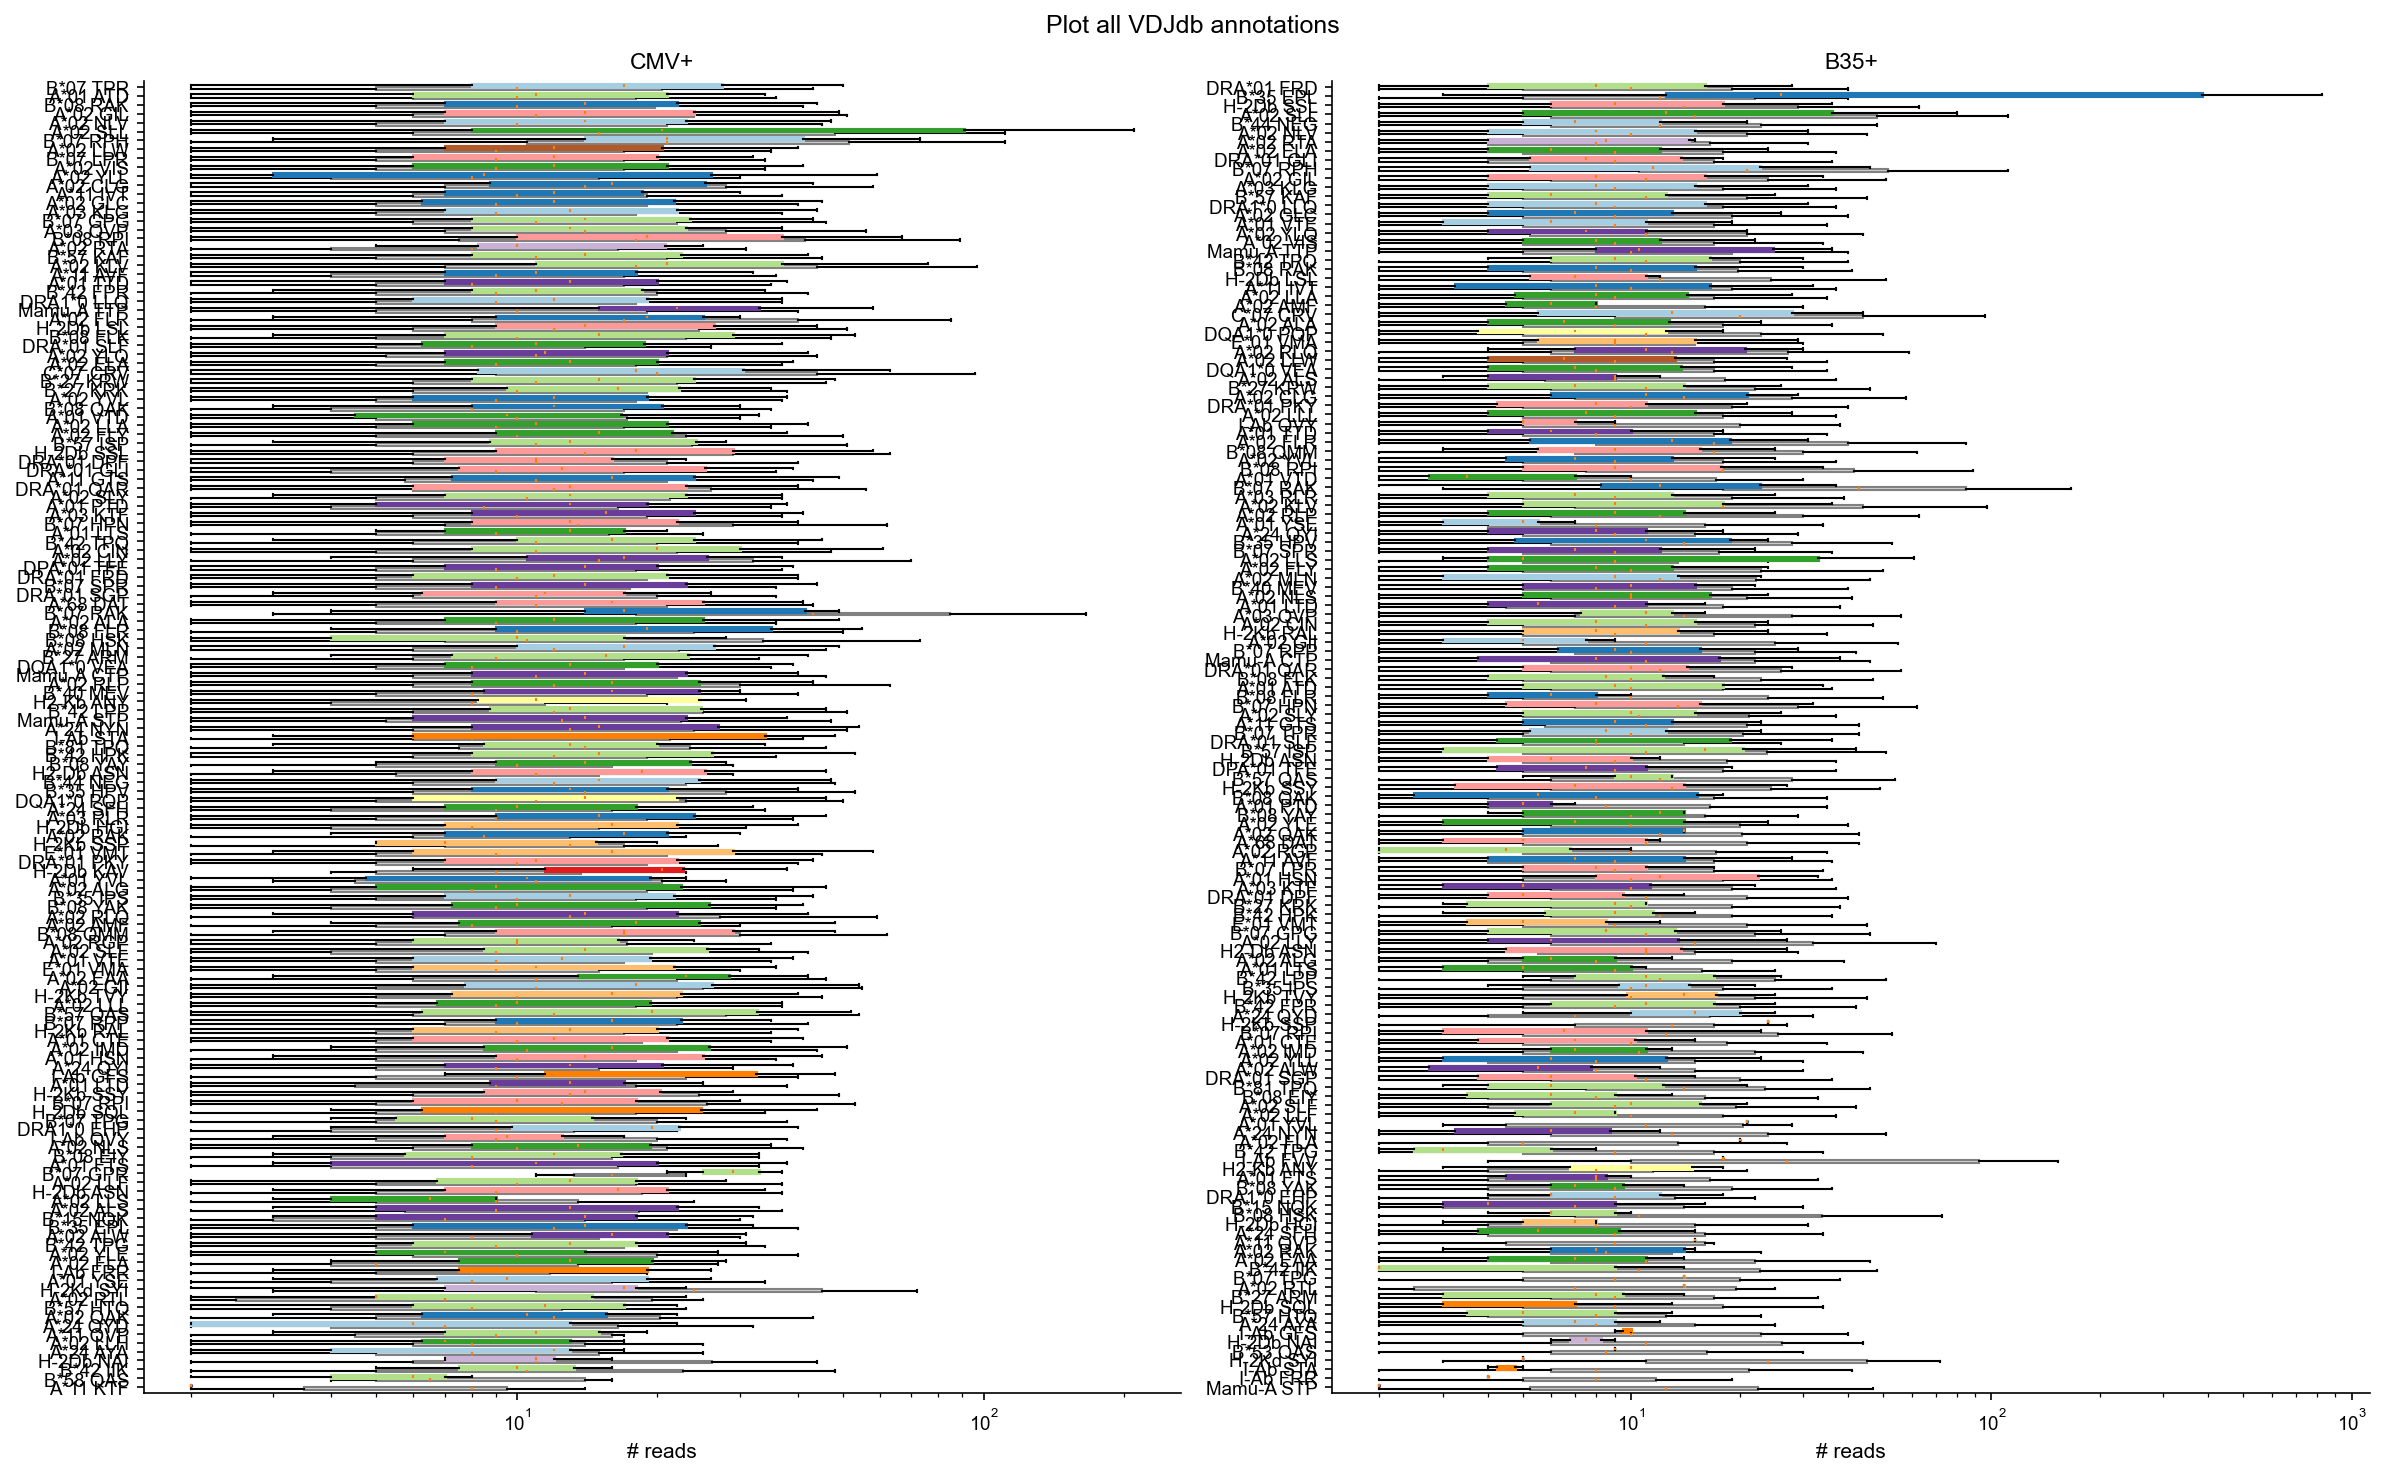

,sample_id,epi.name,p.value,p.value.adj
182,CMV+,A*02 NLV,9.674646e-59,2.815322e-56
198,CMV+,A*03 KLG,2.029298e-56,2.952629e-54
37,B35+,A*02 NLV,1.564193e-53,1.517267e-51
25,B35+,A*02 GIL,1.283083e-31,9.334429e-30
169,CMV+,A*02 GIL,1.273074e-17,7.409290e-16
...,...,...,...,...
263,CMV+,DRA*01 QAR,9.602773e-01,9.736610e-01
43,B35+,A*02 RTA,9.812679e-01,9.914894e-01
152,CMV+,A*01 VTD,1.000000e+00,1.000000e+00
60,B35+,A*11 QVP,1.000000e+00,1.000000e+00


In [5]:
plot_boxpanels(df_vdjdb, df_vdjdb_control, 'Plot all VDJdb annotations')
wilcox_by_epitope(df_vdjdb, df_vdjdb_control)

## Zoom in and filter based on donor HLA haplotype knowledge

For the CMV+ donor keep only CMV annotations compatible with donor HLA. For the B35+ donor keep only non-CMV annotations compatible with donor HLA.

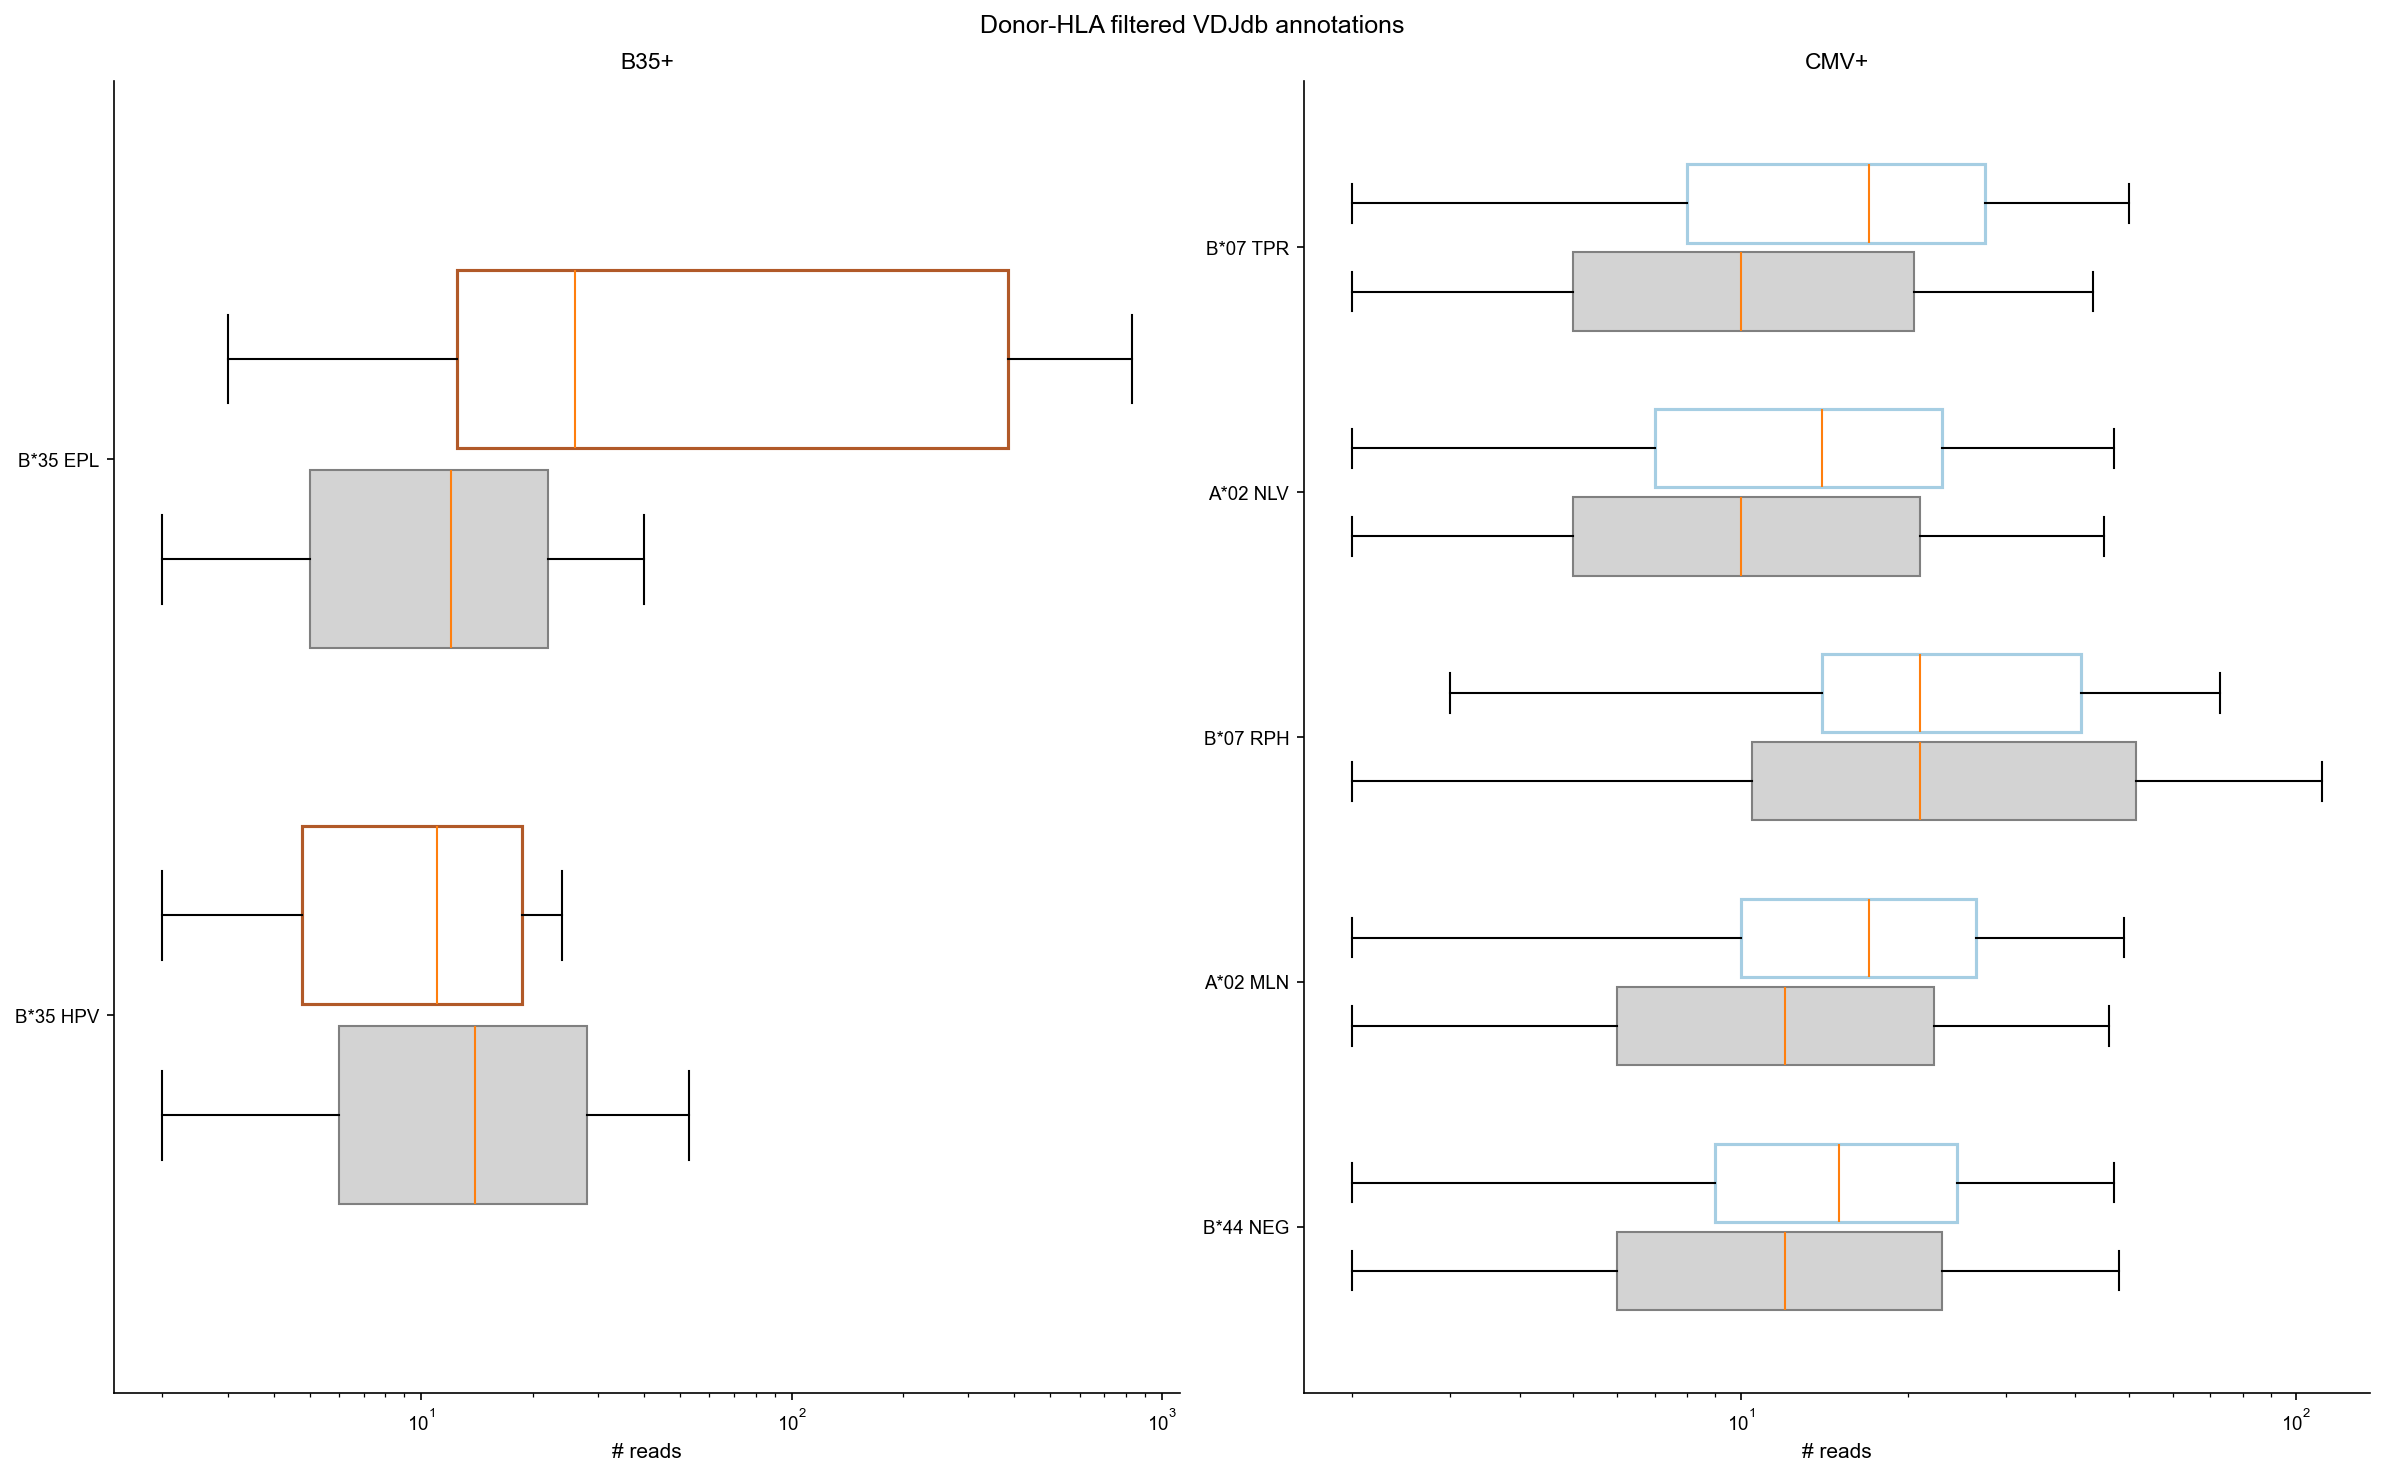

,sample_id,epi.name,p.value,p.value.adj
3,CMV+,A*02 NLV,9.674646e-59,6.772252e-58
0,B35+,B*35 EPL,1.162456e-04,2.856093e-04
5,CMV+,B*07 TPR,1.224040e-04,2.856093e-04
2,CMV+,A*02 MLN,9.842690e-03,1.722471e-02
6,CMV+,B*44 NEG,2.828507e-02,3.959909e-02
1,B35+,B*35 HPV,3.344690e-01,3.902138e-01
4,CMV+,B*07 RPH,8.518887e-01,8.518887e-01


In [6]:
df_vdjdb_f = donor_filter(df_vdjdb)
df_vdjdb_c = donor_control_filter(df_vdjdb_control)

plot_boxpanels(df_vdjdb_f, df_vdjdb_c, 'Donor-HLA filtered VDJdb annotations')
wilcox_by_epitope(df_vdjdb_f, df_vdjdb_c)

## Search for expanded TCR groups with TCRNET

Run TCRNET against the full control repertoire, adjust P-values, select enriched clonotypes, and compare fold enrichment with a synthetic control of size $10^7$.

In [7]:
cmv_tcrnet = compute_tcrnet(
    cmv_rep_full,
    control=control_rep_full,
    metric='hamming',
    threshold=1,
    match_mode='vj',
    pvalue_mode='binomial',
    n_jobs=CORES,
)
b35_tcrnet = compute_tcrnet(
    b35_rep_full,
    control=control_rep_full,
    metric='hamming',
    threshold=1,
    match_mode='vj',
    pvalue_mode='binomial',
    n_jobs=CORES,
)

df_tcrnet = pd.concat(
    [
        tcrnet_table_with_counts(cmv_rep_full, 'CMV+', cmv_tcrnet.table),
        tcrnet_table_with_counts(b35_rep_full, 'B35+', b35_tcrnet.table),
    ],
    ignore_index=True,
)
df_tcrnet_e = df_tcrnet[df_tcrnet['p.adj'].lt(0.05)].copy()
df_tcrnet_e.groupby('sample_id').agg(enriched_clonotypes=('cdr3aa', 'count'))

AttributeError: 'DataFrame' object has no attribute 'merge'

## Synthetic-control comparison

This is the only analysis block added on top of the reference workflow: compare fold enrichment from the full control repertoire against a synthetic control of size $10^7$.

In [8]:
from mir.common.control import ControlManager

In [9]:
mgr = ControlManager()

synth_specs = {
    'CMV+': {'rep': cmv_rep_full, 'seed': 42},
    'B35+': {'rep': b35_rep_full, 'seed': 43},
}

synth_tables: list[pd.DataFrame] = []
for sample_id, spec in synth_specs.items():
    synth_path = mgr.synthetic_control_path('human', 'TRB', 10_000_000)
    if not synth_path.exists():
        print(f"Synthetic control cache missing for n=10^7 at {synth_path}; skipping synthetic comparison for {sample_id}.")
        continue

    synth_result = compute_tcrnet(
        spec['rep'],
        control_type='synthetic',
        species='human',
        control_manager=mgr,
        control_kwargs={'n': 10_000_000, 'seed': spec['seed'], 'chunk_size': 100_000, 'progress': True},
        normalize_control_vj_usage=True,
        metric='hamming',
        threshold=1,
        match_mode='vj',
        pvalue_mode='binomial',
        n_jobs=CORES,
    )
    synth_tables.append(tcrnet_table_with_counts(spec['rep'], sample_id, synth_result.table))

if synth_tables:
    df_tcrnet_synth = pd.concat(synth_tables, ignore_index=True)

    comparison = (
        df_tcrnet[['sample_id', 'cdr3aa', 'fold', 'p.adj']]
        .rename(columns={'fold': 'fold_real', 'p.adj': 'p_real'})
        .merge(
            df_tcrnet_synth[['sample_id', 'cdr3aa', 'fold', 'p.adj']].rename(columns={'fold': 'fold_synth', 'p.adj': 'p_synth'}),
            on=['sample_id', 'cdr3aa'],
            how='inner',
        )
    )

    ann_cols = ['sample_id', 'cdr3aa', 'antigen.epitope', 'mhc.a', 'mhc.b']
    ann_available = [c for c in ann_cols if c in df_vdjdb_f.columns]
    if ann_available:
        comparison = comparison.merge(df_vdjdb_f[ann_available].drop_duplicates(), on=['sample_id', 'cdr3aa'], how='left')

    epi = comparison.get('antigen.epitope', pd.Series('', index=comparison.index)).fillna('')
    mhc_b = comparison.get('mhc.b', pd.Series('', index=comparison.index)).fillna('')

    comparison['highlight'] = np.select(
        [
            comparison['sample_id'].eq('B35+') & epi.str.contains('EPL', na=False),
            comparison['sample_id'].eq('CMV+') & (epi.str.contains('TPR', na=False) | mhc_b.str.contains('B\*07', na=False, regex=True)),
        ],
        ['B35 EBV epitope', 'B07 CMV epitope'],
        default='other',
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
    for ax, sid in zip(axes[0], ['CMV+', 'B35+']):
        sub = comparison[comparison['sample_id'].eq(sid)].copy()
        if sub.empty:
            ax.set_title(f"{sid} (no synthetic-control overlap)")
            ax.set_axis_off()
            continue

        base = sub[sub['highlight'].eq('other')]
        if not base.empty:
            ax.scatter(base['fold_real'], base['fold_synth'], s=12, alpha=0.45, color='lightgray', label='other')

        palette = {'B35 EBV epitope': '#d62728', 'B07 CMV epitope': '#1f77b4'}
        for label, color in palette.items():
            h = sub[sub['highlight'].eq(label)]
            if h.empty:
                continue
            ax.scatter(h['fold_real'], h['fold_synth'], s=28, alpha=0.95, color=color, label=label)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Fold enrichment vs real control')
        ax.set_ylabel('Fold enrichment vs synthetic control (10^7)')
        ax.set_title(sid)
        ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('Synthetic-control comparison skipped: no cached 10^7 synthetic control available.')

Synthetic control cache missing for n=10^7 at /Users/mikesh/.cache/mirpy/controls/synthetic/human/TRB/olga_n10000000.pkl; skipping synthetic comparison for CMV+.
Synthetic control cache missing for n=10^7 at /Users/mikesh/.cache/mirpy/controls/synthetic/human/TRB/olga_n10000000.pkl; skipping synthetic comparison for B35+.
Synthetic-control comparison skipped: no cached 10^7 synthetic control available.


## Correlation between enrichment fold and clonotype frequency

Plot enriched clonotypes, coloring by adjusted significance.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
for ax, sample_id in zip(axes[0], ['CMV+', 'B35+']):
    sub = df_tcrnet_e[df_tcrnet_e['sample_id'].eq(sample_id)].copy()
    if sub.empty:
        continue
    scatter = ax.scatter(
        sub['freq'],
        sub['fold'],
        c=-np.log10(np.maximum(sub['p.adj'], 1e-300)),
        cmap='RdBu_r',
        s=20,
        alpha=0.8,
    )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Enrichment fold')
    ax.set_title(sample_id)
    plt.colorbar(scatter, ax=ax, label='-log10 adjusted P-value')
plt.tight_layout()
plt.show()

df_tcrnet_e.groupby('sample_id').apply(lambda x: pd.Series({'spearman_r': spearmanr(x['fold'], x['freq']).statistic, 'p_value': spearmanr(x['fold'], x['freq']).pvalue}))

/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_20353/1763834344.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,spearman_r,p_value
sample_id,,
B35+,0.013338,0.797912
CMV+,0.245055,0.005682


## Extract enriched groups of homologous TCRs

Compute Hamming-distance graphs for random top-3000 clonotypes and for the neighborhoods around enriched clonotypes.

In [11]:
def layout_graph_df(node_df: pd.DataFrame, sample_id: str) -> pd.DataFrame:
    if node_df.empty:
        return pd.DataFrame(columns=['cdr3aa', 'x', 'y', 'cid', 'cid2', 'sample_id', 'freq', 'count'])
    graph = build_edit_distance_graph(sequences_to_clonotypes(node_df), metric='hamming', threshold=1, nproc=CORES)
    coords = np.asarray(graph.layout_graphopt(niter=3000, node_charge=0.005)) if graph.vcount() else np.empty((0, 2))
    membership = graph.components().membership if graph.vcount() else []
    layout = pd.DataFrame(
        {
            'cdr3aa': graph.vs['name'],
            'x': coords[:, 0] if len(coords) else [],
            'y': coords[:, 1] if len(coords) else [],
            'cid': membership,
            'sample_id': sample_id,
        }
    )
    layout['cid2'] = layout['sample_id'] + '_C' + layout['cid'].astype(str)
    return layout.merge(node_df[['cdr3aa', 'freq', 'count']].drop_duplicates(), on='cdr3aa', how='left')

In [12]:
def plot_graph_panels(df_layout: pd.DataFrame, color_by: str | None, title: str, annotate_only: bool = False) -> None:
    sample_ids = list(df_layout['sample_id'].drop_duplicates())
    fig, axes = plt.subplots(1, len(sample_ids), figsize=(7 * len(sample_ids), 6), squeeze=False)
    for ax, sample_id in zip(axes[0], sample_ids):
        sub = df_layout[df_layout['sample_id'].eq(sample_id)].copy()
        if sub.empty:
            continue
        sizes = np.sqrt(sub['freq'].fillna(0).to_numpy() + 1e-12) * 200
        if annotate_only:
            ax.scatter(sub['x'], sub['y'], s=np.maximum(sizes, 10), color='lightgrey', alpha=0.35)
            colored = sub[sub[color_by].notna()].copy()
            if not colored.empty:
                for label, grp in colored.groupby(color_by):
                    ax.scatter(grp['x'], grp['y'], s=np.maximum(np.sqrt(grp['freq'].to_numpy() + 1e-12) * 220, 14), label=label, alpha=0.9)
                ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=8)
        elif color_by is None:
            ax.scatter(sub['x'], sub['y'], s=np.maximum(sizes, 10), color='dimgray', alpha=0.9)
        else:
            ax.scatter(sub['x'], sub['y'], s=np.maximum(sizes, 10), c=sub[color_by], cmap='Set1', alpha=0.9)
        ax.set_title(sample_id)
        ax.set_xlabel('MDS1')
        ax.set_ylabel('MDS2')
        ax.set_aspect('equal', adjustable='datalim')
        ax.grid(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [13]:
sequence_tables = {
    'CMV+': repertoire_to_sequence_table(cmv_rep_full, 'CMV+'),
    'B35+': repertoire_to_sequence_table(b35_rep_full, 'B35+'),
}

random_layouts = []
enriched_layouts = []
for sample_id, rep in [('CMV+', cmv_rep_full), ('B35+', b35_rep_full)]:
    seq_table = sequence_tables[sample_id]
    rnd_nodes = (
        seq_table[~seq_table['cdr3aa'].str.contains(r'[_*]', regex=True, na=False)]
        .sort_values('count', ascending=False)
        .head(3000)
        .copy()
    )
    random_layouts.append(layout_graph_df(rnd_nodes, sample_id))

    enriched_seqs = df_tcrnet_e[df_tcrnet_e['sample_id'].eq(sample_id)]['cdr3aa'].drop_duplicates().tolist()
    neighbor_seqs = collect_neighbor_sequences(rep, enriched_seqs)
    enriched_nodes = seq_table[seq_table['cdr3aa'].isin(neighbor_seqs)].copy()
    enriched_layouts.append(layout_graph_df(enriched_nodes, sample_id))

df_mds_rnd = pd.concat(random_layouts, ignore_index=True)
df_mds = pd.concat(enriched_layouts, ignore_index=True)

df_mds[['sample_id', 'cid2']].drop_duplicates().groupby('sample_id').size().rename('n_components')

sample_id
B35+    125
CMV+     43
Name: n_components, dtype: int64

## Layout and plot graphs

Show the random top-3000 graph in grey and the enriched-neighborhood graph colored by connected component.

In [14]:
plot_graph_panels(df_mds_rnd, color_by=None, title='Random graph: top 3000 clonotypes')
plot_graph_panels(df_mds, color_by='cid', title='Enriched-clonotype neighborhoods colored by connected component')

/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_20353/2796074657.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Combine TCRNET results and VDJdb annotations

Color enriched-graph nodes by donor-filtered VDJdb annotations and compute annotation enrichment for connected components.

In [15]:
annot_cols = df_vdjdb_f[['cdr3aa', 'epi.name', 'sample_id', 'antigen.species']].drop_duplicates().copy()
annot_cols['epi.name'] = annot_cols['antigen.species'].astype(str) + ' ' + annot_cols['epi.name'].astype(str)
annot_cols = annot_cols[['cdr3aa', 'epi.name', 'sample_id']]

df_mds_ag_freq = df_mds.merge(annot_cols, on=['cdr3aa', 'sample_id'], how='left')
plot_graph_panels(df_mds_ag_freq, color_by='epi.name', title='Enriched graphs colored by donor-filtered VDJdb annotation', annotate_only=True)

cluster_annot_stats = cluster_annotation_stats(df_mds_ag_freq)
cluster_annot_stats.head(20)

/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_20353/2796074657.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,sample_id,cid2,epi.name,total.sample,total.epi,total.cluster,count.matched,fraction.matched,fraction.matched.e,p.value,p.value.adj
0,B35+,B35+_C0,EBV B*35 EPL,885,21,40,21,0.525000,0.023729,6.457089e-24,1.614272e-22
22,CMV+,CMV+_C7,CMV B*07 RPH,444,27,47,27,0.574468,0.060811,4.291258e-21,5.364072e-20
1,B35+,B35+_C27,EBV B*35 HPV,885,7,20,6,0.300000,0.007910,8.629575e-09,7.191312e-08
23,CMV+,CMV+_C7,CMV B*07 TPR,444,8,47,8,0.170213,0.018018,1.865743e-06,1.166089e-05
12,CMV+,CMV+_C26,CMV A*02 NLV,444,44,7,5,0.714286,0.099099,1.689672e-04,8.448358e-04
13,CMV+,CMV+_C27,CMV A*02 NLV,444,44,18,6,0.333333,0.099099,6.136393e-03,2.556830e-02
21,CMV+,CMV+_C42,CMV A*02 NLV,444,44,5,3,0.600000,0.099099,8.342831e-03,2.979582e-02
3,CMV+,CMV+_C10,CMV A*02 MLN,444,2,36,2,0.055556,0.004505,1.154791e-02,3.608723e-02
2,B35+,B35+_C92,EBV B*35 HPV,885,7,3,1,0.333333,0.007910,2.354162e-02,6.539340e-02
14,CMV+,CMV+_C29,CMV A*02 NLV,444,44,4,2,0.500000,0.099099,5.142740e-02,1.168804e-01


## Interesting annotated clusters

Inspect components with the strongest excess of donor-compatible VDJdb annotations and show the matched clonotypes.

In [16]:
top_clusters = cluster_annot_stats[cluster_annot_stats['p.value.adj'].lt(0.05)].head(10).copy()
top_clusters

if not top_clusters.empty:
    interesting = df_mds_ag_freq[df_mds_ag_freq['cid2'].isin(top_clusters['cid2'])].copy()
    plot_graph_panels(interesting, color_by='epi.name', title='Significant annotated enriched clusters', annotate_only=True)
    display(
        interesting[
            ['sample_id', 'cid2', 'cdr3aa', 'count', 'freq', 'epi.name']
        ].sort_values(['sample_id', 'cid2', 'count'], ascending=[True, True, False]).head(50)
    )

/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_20353/2796074657.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,sample_id,cid2,cdr3aa,count,freq,epi.name
448,B35+,B35+_C0,CAIGTGDSNQPQHF,13369,0.015446,EBV B*35 EPL
1189,B35+,B35+_C0,CATSTGDSNQPQHF,3165,0.003657,EBV B*35 EPL
1063,B35+,B35+_C0,CASSTGDSNQPQHF,2929,0.003384,EBV B*35 EPL
455,B35+,B35+_C0,CAISTGDSNQPQHF,2113,0.002441,EBV B*35 EPL
1171,B35+,B35+_C0,CATGTGDSNQPQHF,1886,0.002179,EBV B*35 EPL
465,B35+,B35+_C0,CASGTGDSNQPQHF,975,0.001127,EBV B*35 EPL
449,B35+,B35+_C0,CAIGTGDTNQPQHF,533,0.000616,EBV B*35 EPL
1062,B35+,B35+_C0,CASSTGDNNQPQHF,355,0.000410,EBV B*35 EPL
571,B35+,B35+_C0,CASSEPYSNQPQHF,232,0.000268,NaN
476,B35+,B35+_C0,CASNTGDSNQPQHF,206,0.000238,EBV B*35 EPL
